# Results Analysis

Regenerates every figure from the saved CSVs in `notebooks/results/` (no model inference). Figures are saved to `notebooks/new_results/`.

`STT_Comparison-wPrompt wBERT.ipynb` produced the CSVs but used the earlier plotting code, so its embedded figures are outdated.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent)) #repo root, so `src` is importable from notebooks/

from src.aggregate import build_summary_report
from src.config import LATENCY_RESULTS_FILENAME, COST_EFFICIENCY_FILENAME, ACCENT_RESULTS_FILENAME, BERT_SCORES_FILENAME
from src.io_utils import load_results
from src.plots import (save_figure, plot_accuracy_latency, plot_speed_overview, plot_wer_comparison, plot_accuracy_overview,
                       plot_semantic_overview, plot_prompt_shift, plot_radar_profiles, plot_summary_table)

In [2]:
df_latency = load_results(LATENCY_RESULTS_FILENAME)
df_cost = load_results(COST_EFFICIENCY_FILENAME)
df_accent = load_results(ACCENT_RESULTS_FILENAME)
df_bert = load_results(BERT_SCORES_FILENAME)

## Part 1: Latency and cost

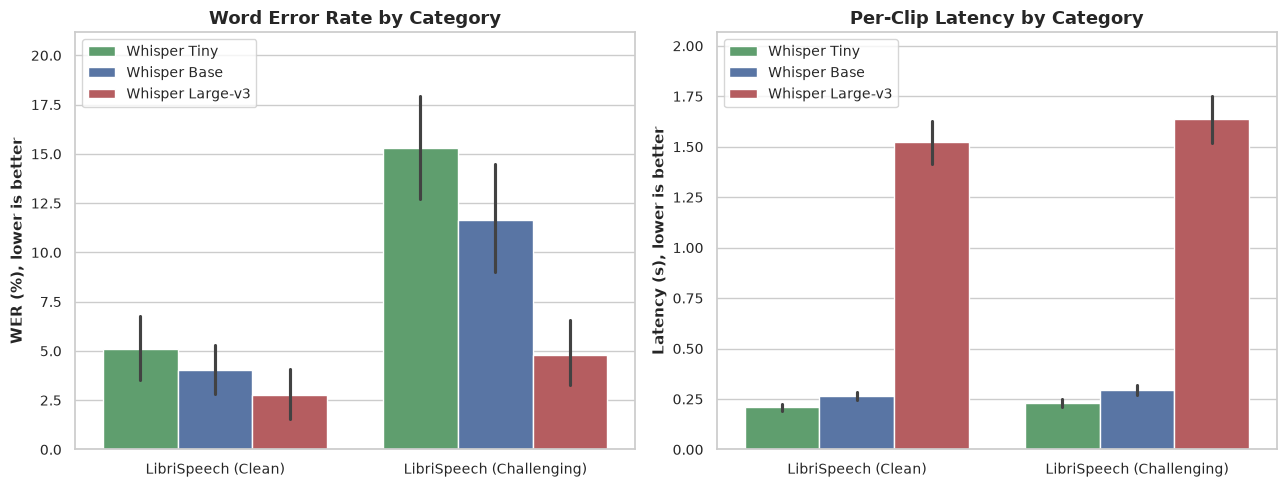

In [3]:
fig = plot_accuracy_latency(df_latency)
save_figure(fig, 'part1_accuracy_latency.png')
plt.show()

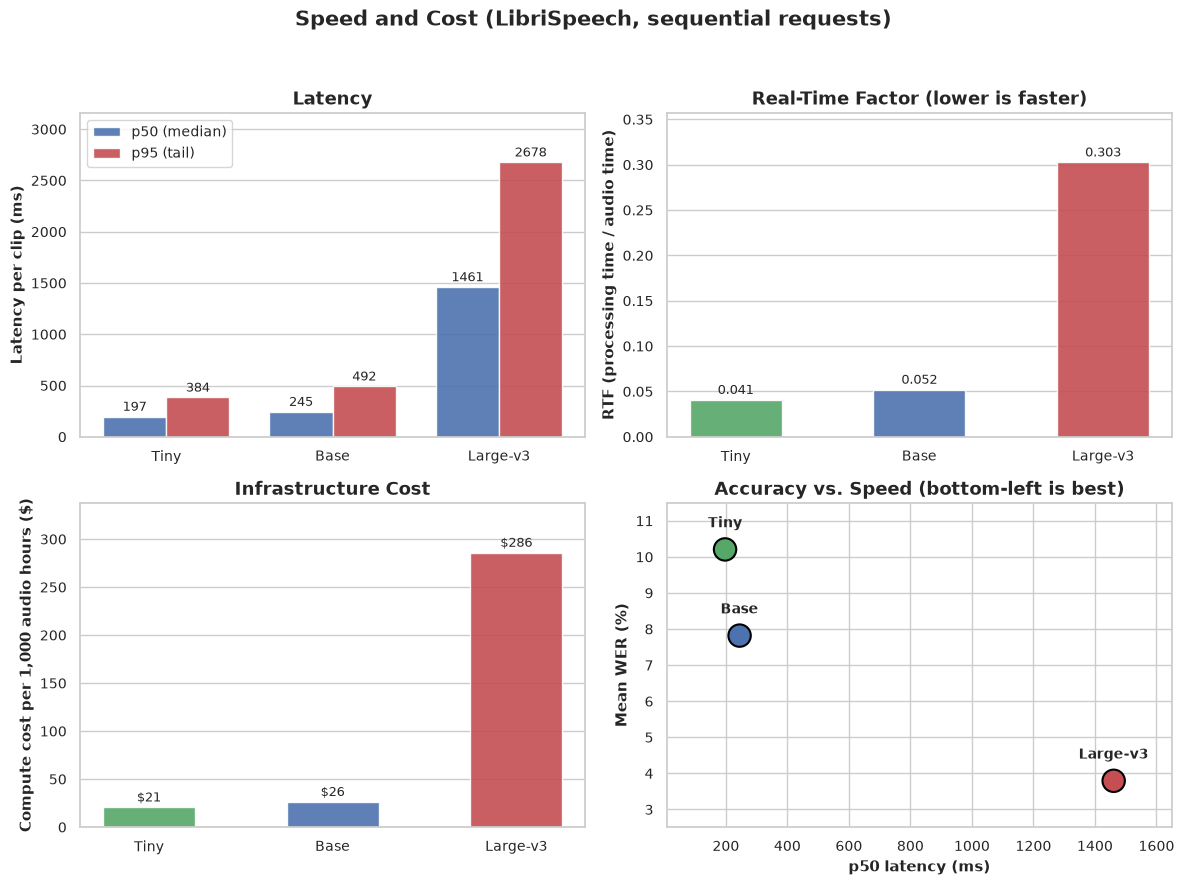

In [4]:
fig = plot_speed_overview(df_latency, df_cost)
save_figure(fig, 'speed_overview.png')
plt.show()

## Part 2: Accent robustness

Prompted WER is unbounded (looping outputs give WER in the thousands), so these figures use medians.

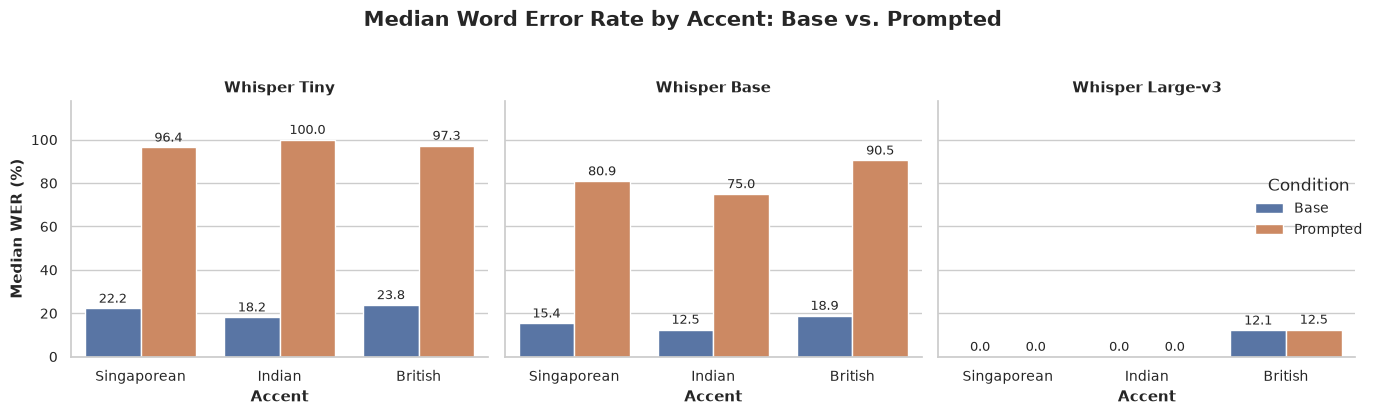

In [5]:
fig = plot_wer_comparison(df_accent)
save_figure(fig, 'wer_by_accent.png')
plt.show()

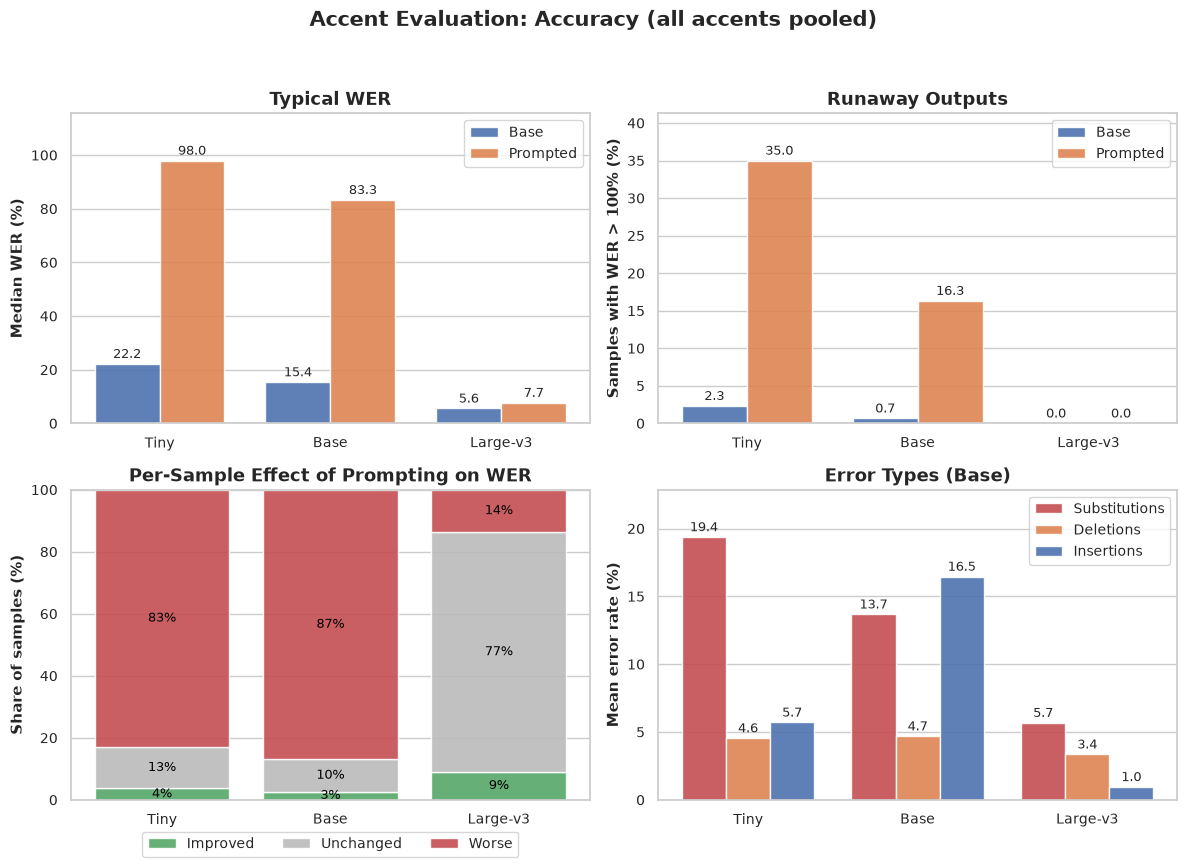

In [6]:
fig = plot_accuracy_overview(df_accent)
save_figure(fig, 'accuracy_overview.png')
plt.show()

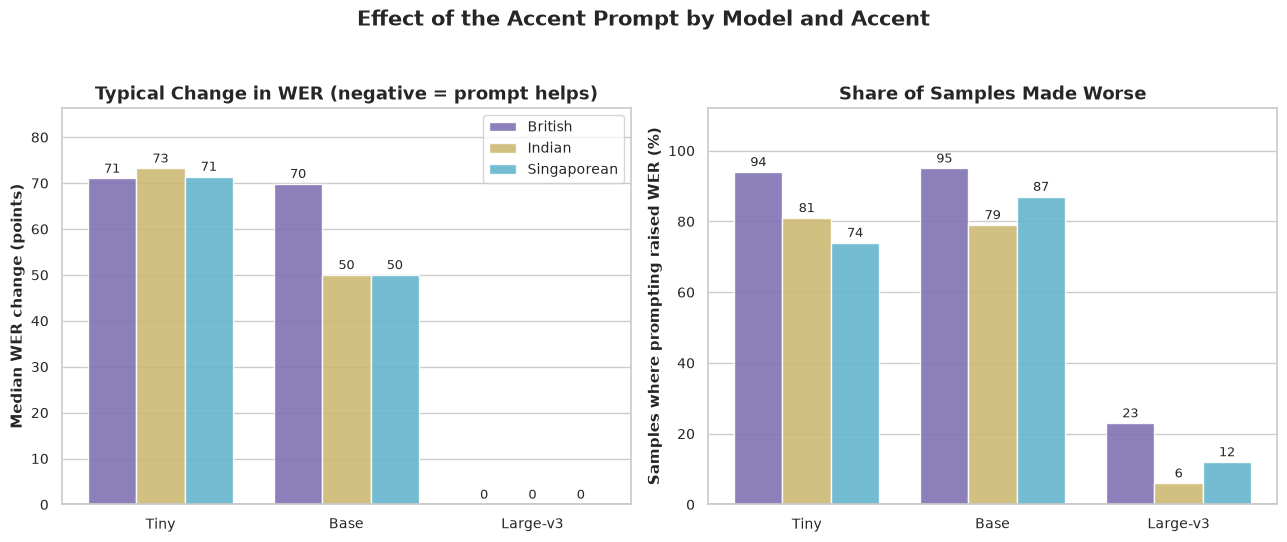

In [7]:
fig = plot_prompt_shift(df_accent)
save_figure(fig, 'prompt_shift.png')
plt.show()

## Part 3: Semantic evaluation

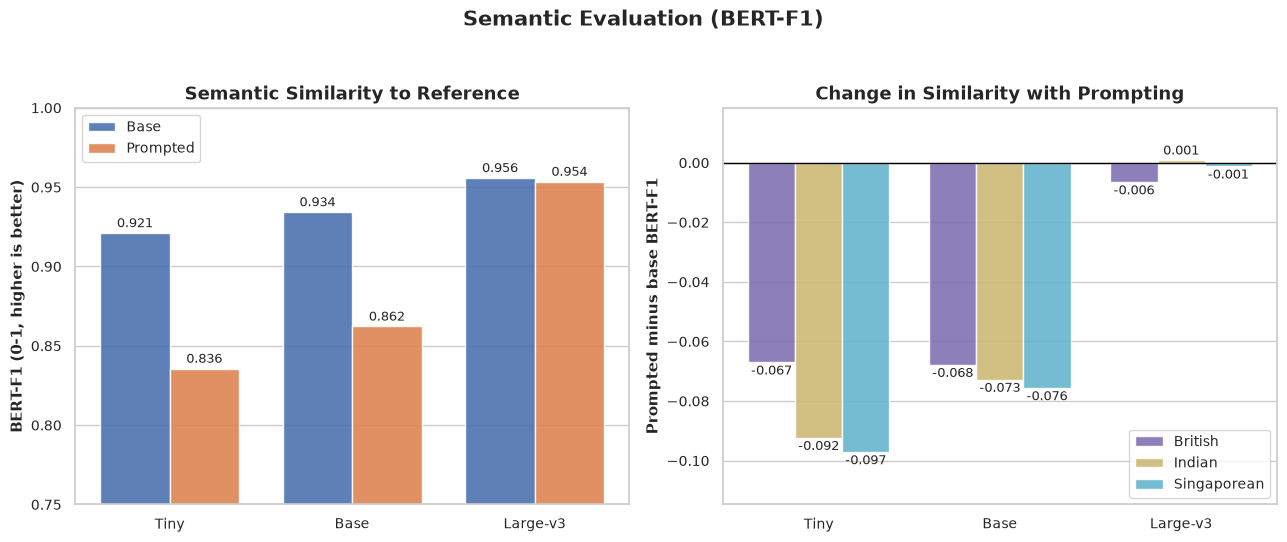

In [8]:
fig = plot_semantic_overview(df_bert)
save_figure(fig, 'semantic_overview.png')
plt.show()

## Part 4: Comparison

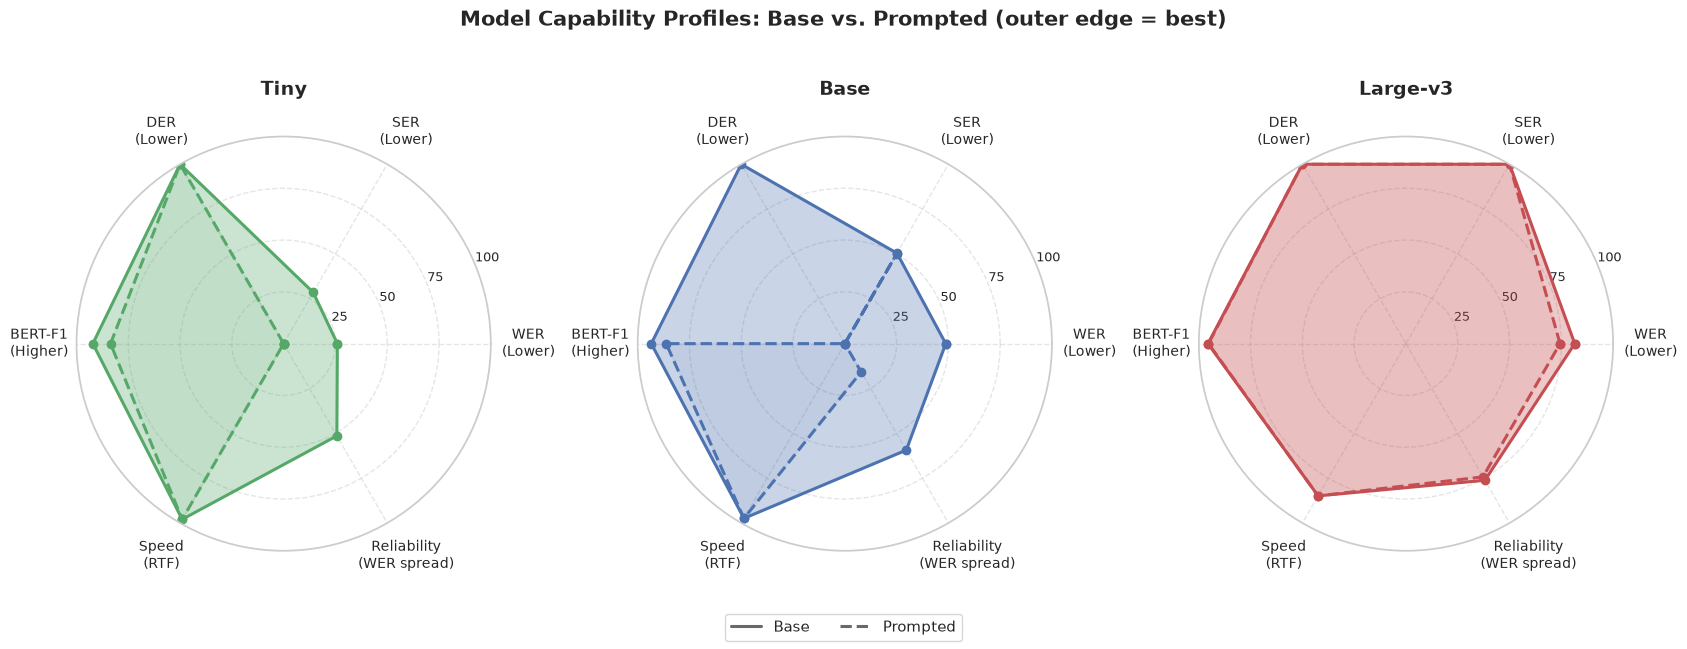

In [9]:
fig = plot_radar_profiles(df_latency, df_accent, df_bert)
save_figure(fig, 'radar_profiles.png')
plt.show()

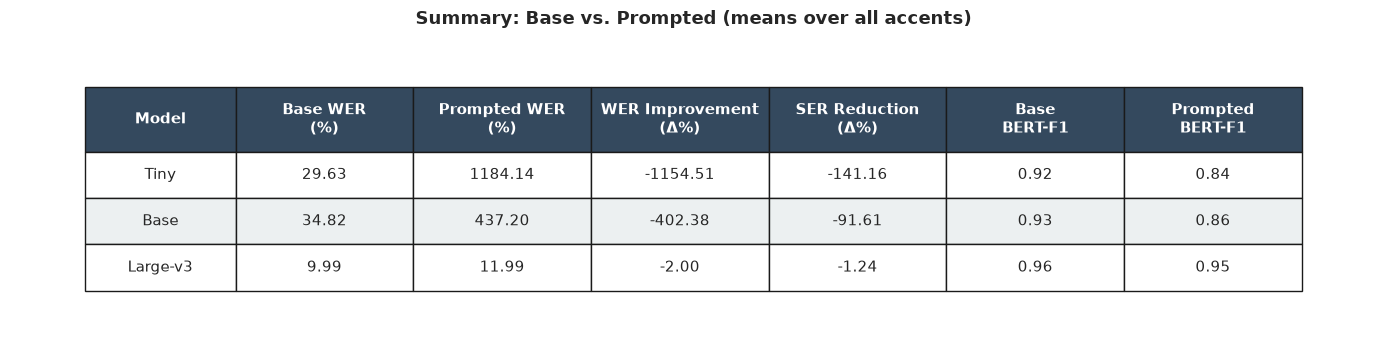

In [10]:
summary_report = build_summary_report(df_accent, df_bert)
fig = plot_summary_table(summary_report)
save_figure(fig, 'summary_table.png')
plt.show()